## DynBet QuickStart

DynBet 是一个**动态下注模拟框架**

只需定义游戏 (Game) 输赢规则并组合策略 (Strategy) 

框架维护余额 (Vault) 与对局历史 (Session)

### 1. 定义游戏

SimpleGame 是一个简单的实现, 从列表轮询获取结果, True 表示赢, False 表示输

In [26]:
from game import Game


class SimpleGame(Game):
    def __init__(self, seq: list[bool]):
        self.seq = seq
        self.index = 0

    def once(self, bet: float) -> float | None:
        won = self.seq[self.index % len(self.seq)]
        self.index += 1
        if won:
            # 赢了,双倍返还
            return bet * 2
        # 输了, 啥也没有 (None)


game = SimpleGame([True])  # 一直赢

### 2. 进行游戏

`Vault` 持有余额与初始下注额

`Session` 管理游戏与余额, 每 `run` 一次就进行一局

In [27]:
from session import Session
from vault import Vault
from strategy import Strategy

vault = Vault(1000.0, 10.0)  # 初始余额为 1000, 每局游戏初始下注 10
session = Session(game, vault)  # 创建会话
print(vault.money)  # 1000.0
session.run(Strategy())  # 以空策略运行一次
print(vault.money)  # 1010.0

1000.0
1010.0


### 3. 游戏策略

策略是一个管道: `Strategy().apply(A).apply(B)` 会依次执行 A 和 B

下面的 `Echo` 是我们调试用的妙妙工具, 它包裹任意策略并把**实际下注额**打印出来, 方便观察

In [28]:
from data import Data


class Echo(Strategy):
    def __init__(self, strategy: Strategy, f: str = "-> %.2f\n"):
        super().__init__()
        self.strategy = strategy
        self.format = f

    def apply(self, strategy: Strategy) -> Strategy:
        self.strategy.apply(strategy)
        return self

    def bet(self, vault: Vault, data: Data) -> Vault:
        bet = self.strategy.bet(vault, data)
        print(self.format % bet.withdrawal, end="")
        return bet

#### 3.1 基础策略

最朴素的几种策略: 平注、按比例、全仓、随机

In [29]:
from strategy import Flat

# 平注
session.run(Echo(Flat(20.0)))  # 下注 20 (覆盖初始下注)
print(vault.money)  # 1030.0

-> 20.00
1030.0


In [30]:
from strategy import Ratio

# 按比例下注
session.run(Echo(Ratio(0.5)))  # 下注初始下注的 50%
print(vault.money)  # 1035.0

-> 5.00
1035.0


In [31]:
from strategy import Allin

# 全仓下注
session.run(Echo(Allin()))  # 下注所有资金
print(vault.money)  # 2070.0

-> 1035.00
2070.0


In [32]:
from strategy import Random

# 在余额范围内随机下注
previous = vault.money
bet = session.run(Echo(Random()))
print(vault.money)

vault.money = 1000.0  # 重置余额

-> 1392.02
3462.016176246024


#### 3.2 组合策略

用 `apply` 把多个策略串成管道

前面的策略修改下注额, 后面的策略在它的基础上继续作用

In [33]:
strategy = Strategy()  # 创建空策略
strategy.apply(Echo(Flat(100.0)))  # 平注 100
strategy.apply(Echo(Ratio(0.5)))  # 缩放 50%
session.run(strategy)
print(vault.money)  # 1050.0

-> 100.00
-> 50.00
1050.0


错误用法: 所有基础策略都不会执行 apply 在它之上的策略

In [34]:
session.run(Echo(Flat(100.0)).apply(Echo(Ratio(0.5))))  # 下注额 100 不会变成 50
print(vault.money)  # 1150.0

-> 100.00
1150.0


通过组合策略, 可以实现许多复杂的策略

例如下注余额的 10%

In [35]:
strategy = Strategy().apply(Echo(Allin())).apply(Echo(Ratio(0.1)))
session.run(strategy)
print(vault.money)  # 1265.0

-> 1150.00
-> 115.00
1265.0


#### 3.3 分支聚合策略

`Aggregator` (`Max`, `Min`, `Sum`) 会**同时**跑管道里的所有子策略, 再按规则聚合

子策略各自拿到余额快照, 互不影响

In [36]:
from strategy import Max, Min, Sum


def apply(target: Strategy):
    # 应用三个平注子策略
    target.apply(Echo(Flat(10.0), "Sub 1 -> %.2f\n"))
    target.apply(Echo(Flat(20.0), "Sub 2 -> %.2f\n"))
    target.apply(Echo(Flat(30.0), "Sub 3 -> %.2f\n"))
    return target

取最大下注额

In [37]:
strategy = apply(Echo(Max(), "Max -> %.2f\n"))  #
session.run(strategy)
print(vault.money)  # 1295.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Max -> 30.00
1295.0


取最小下注额

In [38]:
strategy = apply(Echo(Min(), "Min -> %.2f\n"))
session.run(strategy)
print(vault.money)  # 1305.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Min -> 10.00
1305.0


Sum -> Ratio 取平均下注额

In [39]:
strategy = Strategy().apply(apply(Sum())).apply(Ratio(1 / 3))
strategy = Echo(strategy, "Average -> %.2f\n")
session.run(strategy)
print(vault.money)  # 1325.0

Sub 1 -> 10.00
Sub 2 -> 20.00
Sub 3 -> 30.00
Average -> 20.00
1325.0


#### 3.4 分支选择策略

`Fork` 在主策略和管道之间二选一: 条件成立执行主策略, 否则依次执行管道里的策略

In [40]:
from strategy import Fork

strategy1 = Strategy()
strategy2 = Strategy()
strategy3 = Strategy()
# 基类: 条件成立则执行 strategy1, 否则依次执行 strategy2 -> strategy3 -> ...
fork = Fork(strategy1).apply(strategy2).apply(strategy3)

公平硬币游戏: 赢则翻倍返还, 输则归零

In [41]:
import random


class Coin(Game):
    def once(self, bet: float) -> float | None:
        return bet * 2 if random.randint(0, 1) else None

##### 3.4.1 普通分支选择策略

`Peak` 在**当前余额处于历史最高点**时条件成立

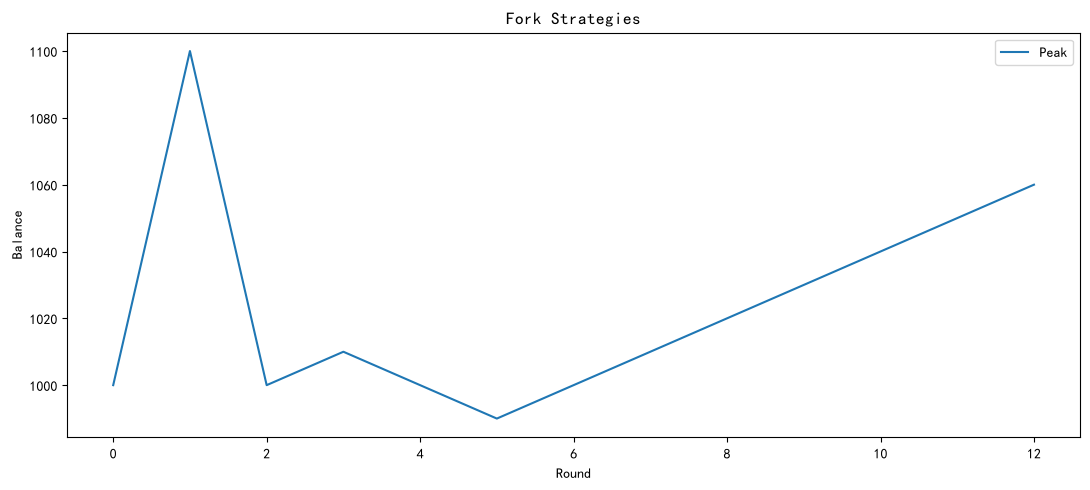

In [42]:
from visualize import Visualizer
from strategy import Peak

game = Coin()
vault = Vault(1000.0, 10.0)
session = Session(game, vault)

# 当余额处于历史最高点时重仓下注 100, 否则保守平注 10
strategy = Peak(Flat(100.0)).apply(Flat(10.0))
for _ in range(12):
    session.run(strategy)

viz = Visualizer("Fork Strategies", "Round", "Balance")


def money(session: Session):
    return [n.vault.money for n in session.data.nodes]


viz.add(money(session), "Peak").show()

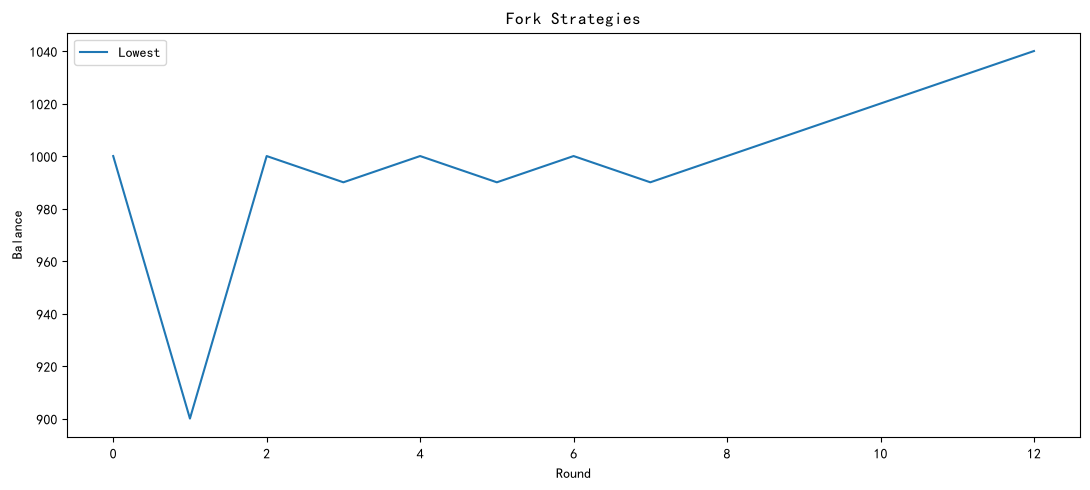

In [43]:
from strategy import Lowest

# 反过来: 处于历史最低点时重仓博反弹
vault = Vault(1000.0, 10.0)
session = Session(game, vault)

strategy = Lowest(Flat(100.0)).apply(Flat(10.0))
for _ in range(12):
    session.run(strategy)

viz.clear()
viz.add(money(session), "Lowest").show()

##### 3.4.2 锁定策略 (Lock)

`Lock` 会先**试算**其内部策略的下注额并存储相应额度, 后续依赖余额的计算会扣掉存储部分

它的条件永远不成立, 管道必定触发


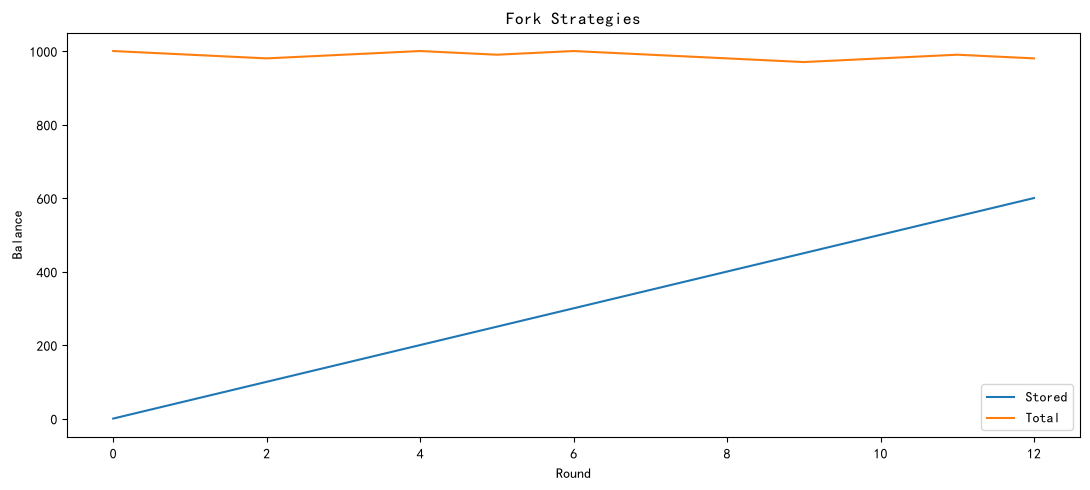

In [44]:
from strategy import Lock

vault = Vault(1000.0, 10.0)
session = Session(game, vault)
# 每局先锁定 50, 再平注 10
strategy = Lock(Flat(50.0)).apply(Flat(10.0))

for _ in range(12):
    session.run(strategy)


def total(session: Session):
    return [node.vault.total for node in session.data.nodes]


def stored(session: Session):
    return [node.vault.stored for node in session.data.nodes]


viz.clear()
viz.add(stored(session), "Stored").add(total(session), "Total").show()

### 3.5. 渐进式策略 (Progressive)

`Progressive` 是一族**根据历史输赢动态调整下注额**的策略

下面用确定性的 `SimpleGame` 把每种策略的下注额变化摆出来看清楚

In [45]:
from strategy import Martingale, DAlembert, Fibonacci, Labouchere, Stepping


def execute(strategy, seq):
    g = SimpleGame(seq)
    v = Vault(1000.0, 10.0)
    s = Session(g, v)
    for _ in range(len(seq)):
        s.run(strategy)
    return s


viz = Visualizer("Progressive", "Round", "Balance")

马丁格尔: 输了翻倍, 赢了复位

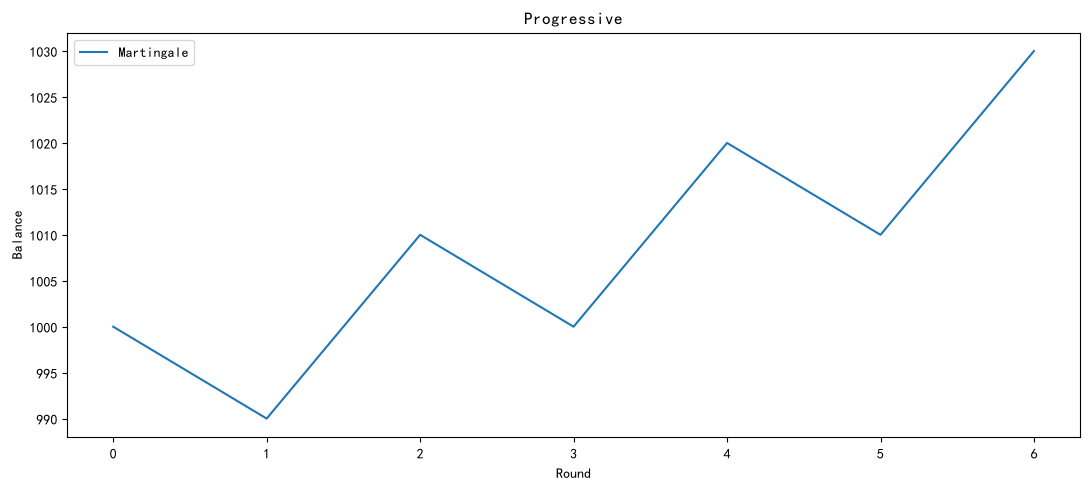

In [46]:
session = execute(Martingale(), [False, True, False, True, False, True])
viz.add(money(session), "Martingale").show()

达朗贝尔: 输了 +1 单位, 赢了 -1 单位

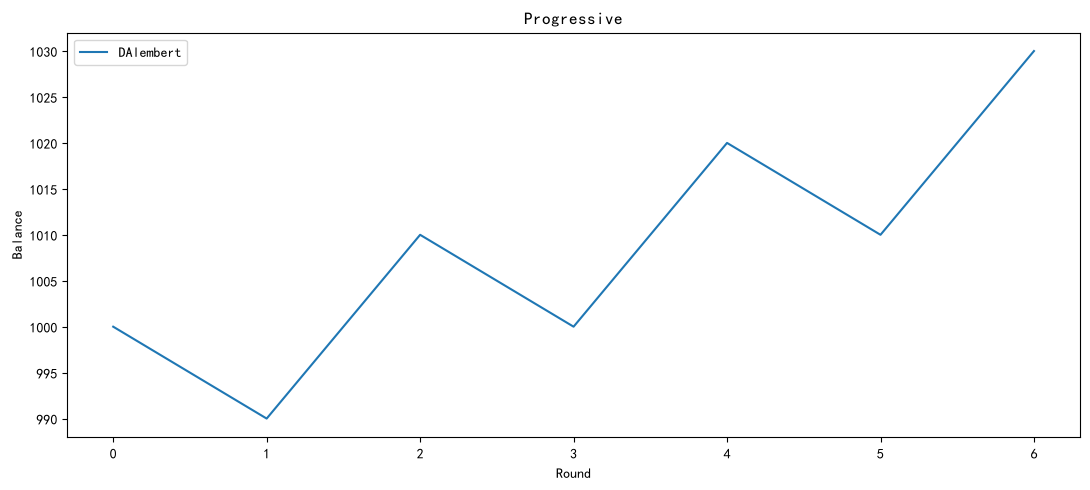

In [47]:
session = execute(DAlembert(), [False, True, False, True, False, True])
viz.clear()
viz.add(money(session), "DAlembert").show()

斐波那契: 赢了沿斐波那契数列前进, 输了回退两步

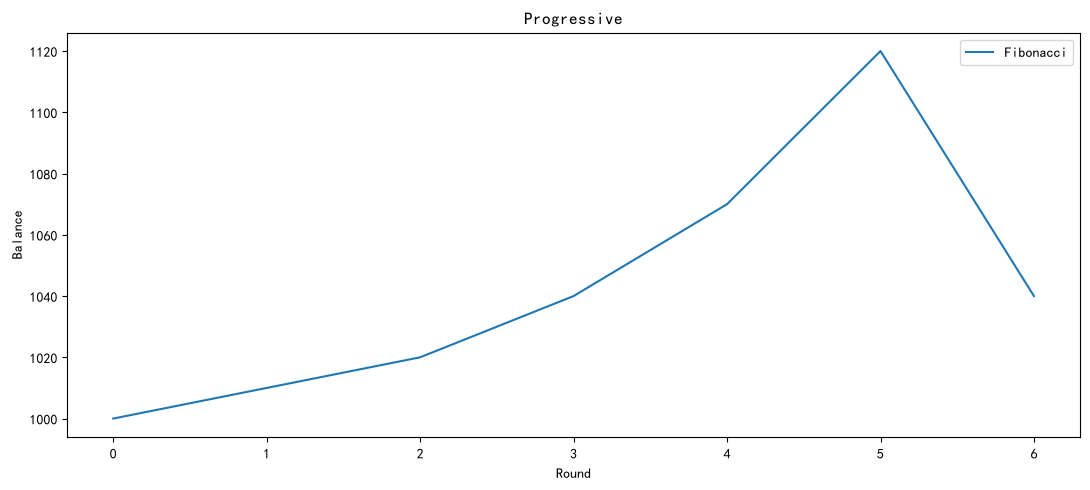

In [48]:
session = execute(Fibonacci(), [True, True, True, True, True, False])
viz.clear()
viz.add(money(session), "Fibonacci").show()

阶梯策略: 连赢时按档位递增, 一输即复位

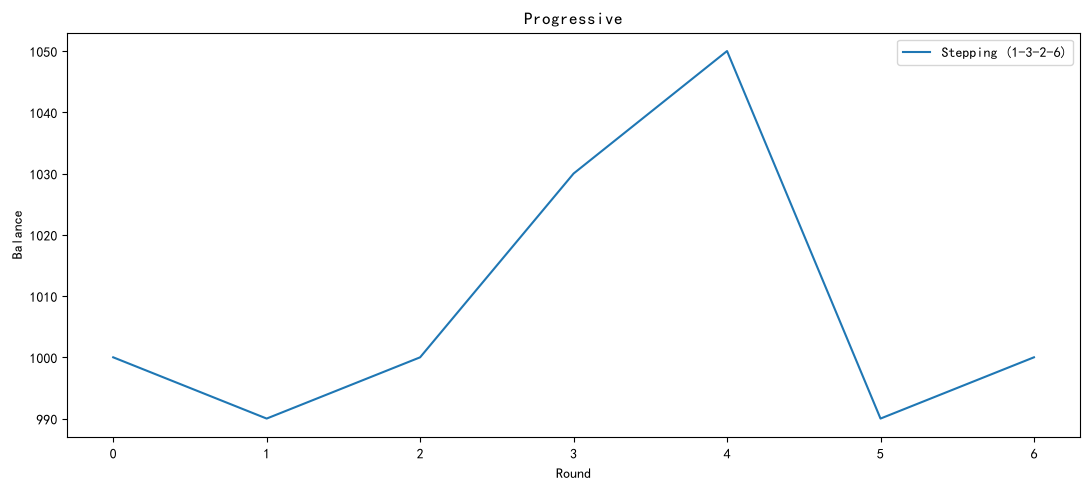

In [49]:
# 经典的 1-3-2-6 系统
session = execute(Stepping([1, 3, 2, 6]), [False, True, True, True, False, True])
viz.clear()
viz.add(money(session), "Stepping (1-3-2-6)").show()

拉博契尔: 下注管道首尾之和, 赢了划掉下注项, 输了把下注项之和加入管道末尾

只有一项时直接根据该项下注, 管道为空时执行内部策略

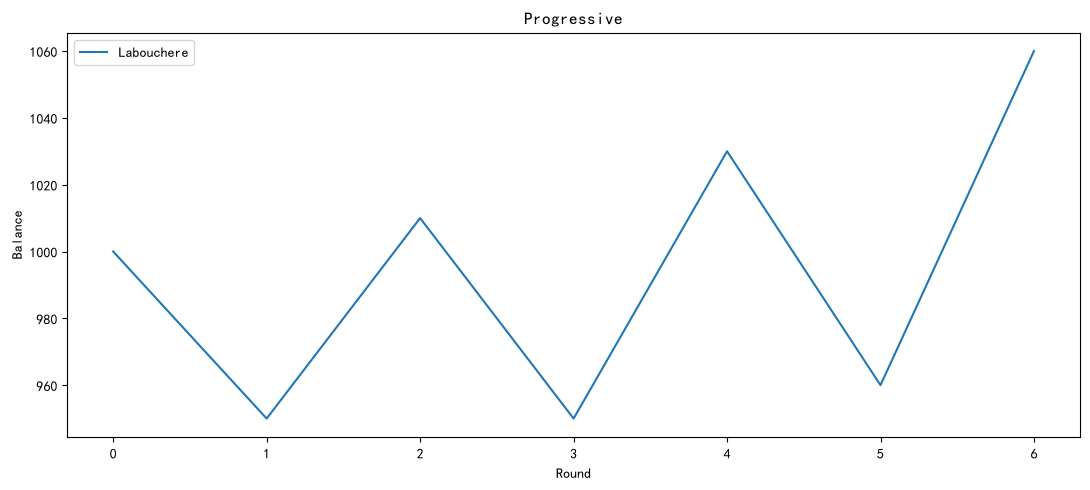

In [50]:
session = execute(
    Labouchere(Flat(10.0))
    .apply(Flat(10.0))
    .apply(Flat(20.0))
    .apply(Flat(30.0))
    .apply(Flat(40.0)),
    [False, True, False, True, False, True],
)
viz.clear()
viz.add(money(session), "Labouchere").show()